In [9]:
file_path="/kaggle/input/datasets/abhishekinnvonix/epilepsy-seizure-dataset-seina-scalp-complete/siena-scalp-eeg-database-1.0.0/PN00/PN00-1.edf"

In [3]:
!pip install mne -q

In [10]:
import mne

In [12]:
raw=mne.io.read_raw_edf(file_path,verbose=False)

/tmp/ipykernel_56/1059737148.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw=mne.io.read_raw_edf(file_path,verbose=False)
/tmp/ipykernel_56/1059737148.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw=mne.io.read_raw_edf(file_path,verbose=False)
/tmp/ipykernel_56/1059737148.py:1: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw=mne.io.read_raw_edf(file_path,verbose=False)


In [13]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG F3, EEG C3, EEG P3, EEG O1, EEG F7, EEG T3, EEG T5, ...
 chs: 35 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2016-01-01 19:39:33 UTC
 nchan: 35
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>

In [15]:
raw.describe()

<RawEDF | PN00-1.edf, 35 x 1344000 (2625.0 s), ~31 KiB, data not loaded>
ch  name     type  unit        min         Q1     median         Q3        max
 0  EEG Fp1  EEG   µV      -709.75      -5.88       3.25      13.00     794.88
 1  EEG F3   EEG   µV      -602.00      -2.37       5.88      13.75     633.12
 2  EEG C3   EEG   µV      -568.62      -2.62       6.38      13.50     300.50
 3  EEG P3   EEG   µV      -657.12      -4.75       7.50      17.50     991.50
 4  EEG O1   EEG   µV     -1187.37      -7.62       8.75      22.25    3182.12
 5  EEG F7   EEG   µV      -654.00      -5.37       7.00      18.62     354.50
 6  EEG T3   EEG   µV      -714.00      -5.12       7.50      16.75     315.00
 7  EEG T5   EEG   µV      -486.00       0.12      11.25      20.38     333.00
 8  EEG Fc1  EEG   µV      -619.00      -1.00       7.12      14.25     281.38
 9  EEG Fc5  EEG   µV      -596.12      -6.25       3.75      12.12     363.88
10  EEG Cp1  EEG   µV      -646.62      -5.12       6.38  

/tmp/ipykernel_56/3515826577.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_56/3515826577.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_56/3515826577.py:1: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Keeping  : ['EEG Fp1', 'EEG F3', 'EEG C3', 'EEG P3', 'EEG O1', 'EEG F7', 'EEG T3', 'EEG T5', 'EEG Fc1', 'EEG Fc5', 'EEG Cp1', 'EEG Cp5', 'EEG F9', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG Fp2', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG O2', 'EEG F8', 'EEG T4', 'EEG T6', 'EEG Fc2', 'EEG Fc6', 'EEG Cp2', 'EEG Cp6', 'EEG F10']
Dropping : ['EKG EKG', 'SPO2', 'HR', '1', '2', 'MK']


/tmp/ipykernel_56/3515826577.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


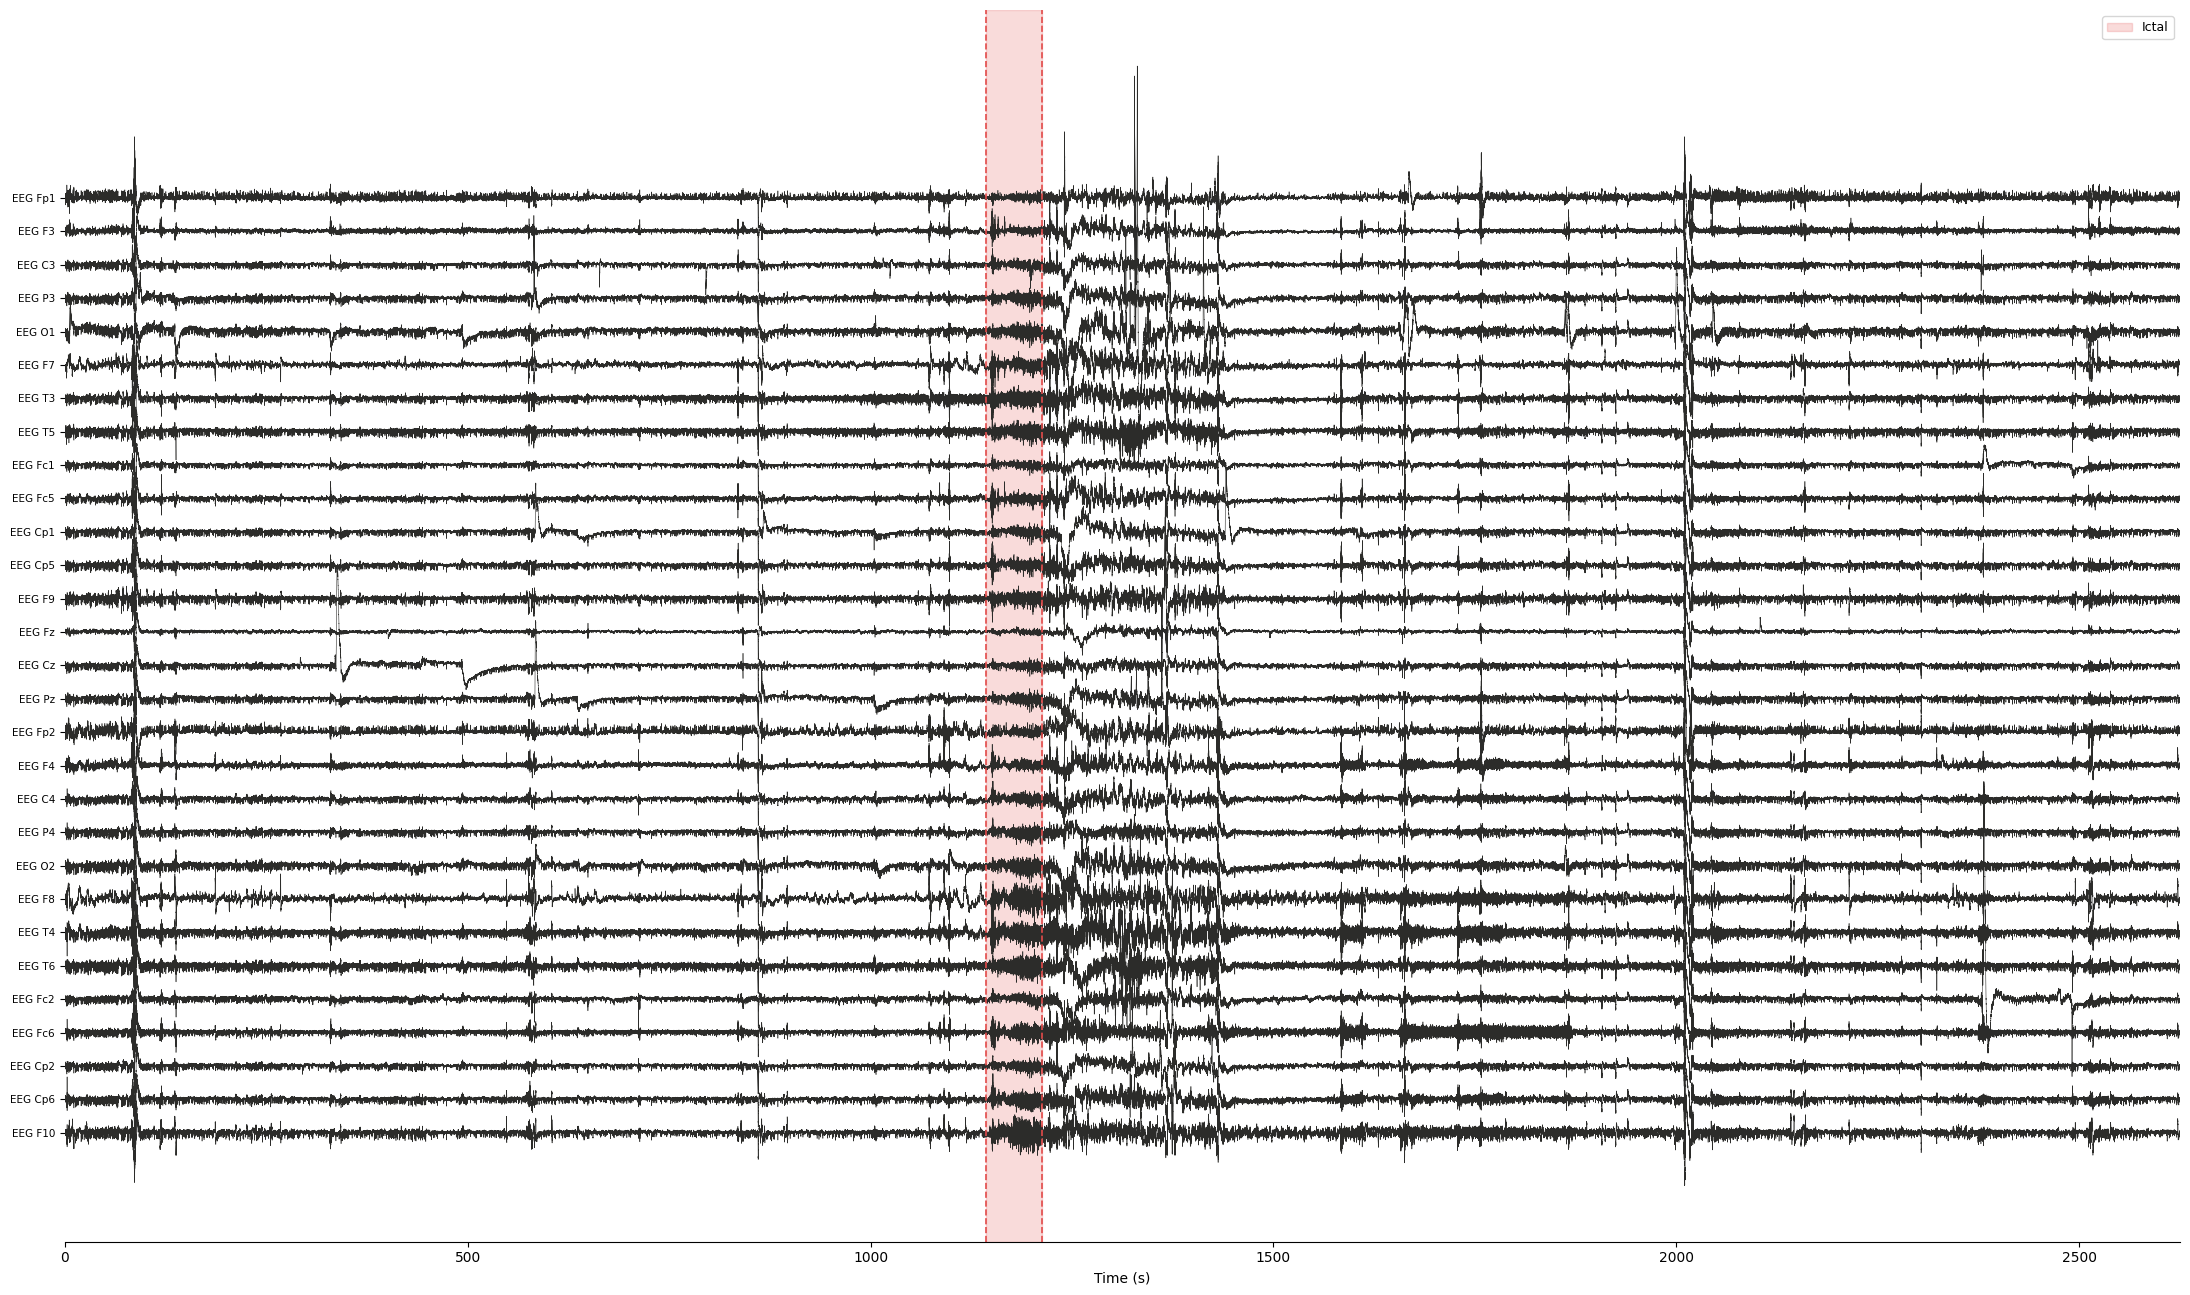

In [20]:
raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

# keep only channels starting with 'EEG '
eeg_chs = [ch for ch in raw.ch_names if ch.startswith('EEG ')]
drop_chs = [ch for ch in raw.ch_names if ch not in eeg_chs]

print(f"Keeping  : {eeg_chs}")
print(f"Dropping : {drop_chs}")

raw.drop_channels(drop_chs)

data, t  = raw.get_data(return_times=True)
data_uv  = data * 1e6
n_ch     = data_uv.shape[0]
ch_names = raw.ch_names
spacing  = 4.0

fig, ax = plt.subplots(figsize=(22, n_ch * 0.45))

for i, ch in enumerate(ch_names):
    offset = (n_ch - 1 - i) * spacing
    ax.plot(t, data_uv[i] * 0.01 + offset, lw=0.4, color='#2c2c2a', rasterized=True)

ax.axvspan(sz_start_sec, sz_end_sec, color='#E24B4A', alpha=0.2, label='Ictal')
ax.axvline(sz_start_sec, color='#E24B4A', lw=1.2, linestyle='--')
ax.axvline(sz_end_sec,   color='#E24B4A', lw=1.2, linestyle='--')

ax.set_yticks([(n_ch - 1 - i) * spacing for i in range(n_ch)])
ax.set_yticklabels(ch_names, fontsize=7.5)
ax.set_xlabel('Time (s)')
ax.set_xlim(t[0], t[-1])
ax.legend(fontsize=9)
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.show()

During postictal there is clear suppression the amplitude drops below the baseline this is the indication  that ictal is completed

/tmp/ipykernel_56/1087469679.py:6: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_56/1087469679.py:6: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_56/1087469679.py:6: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_56/1087469679.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


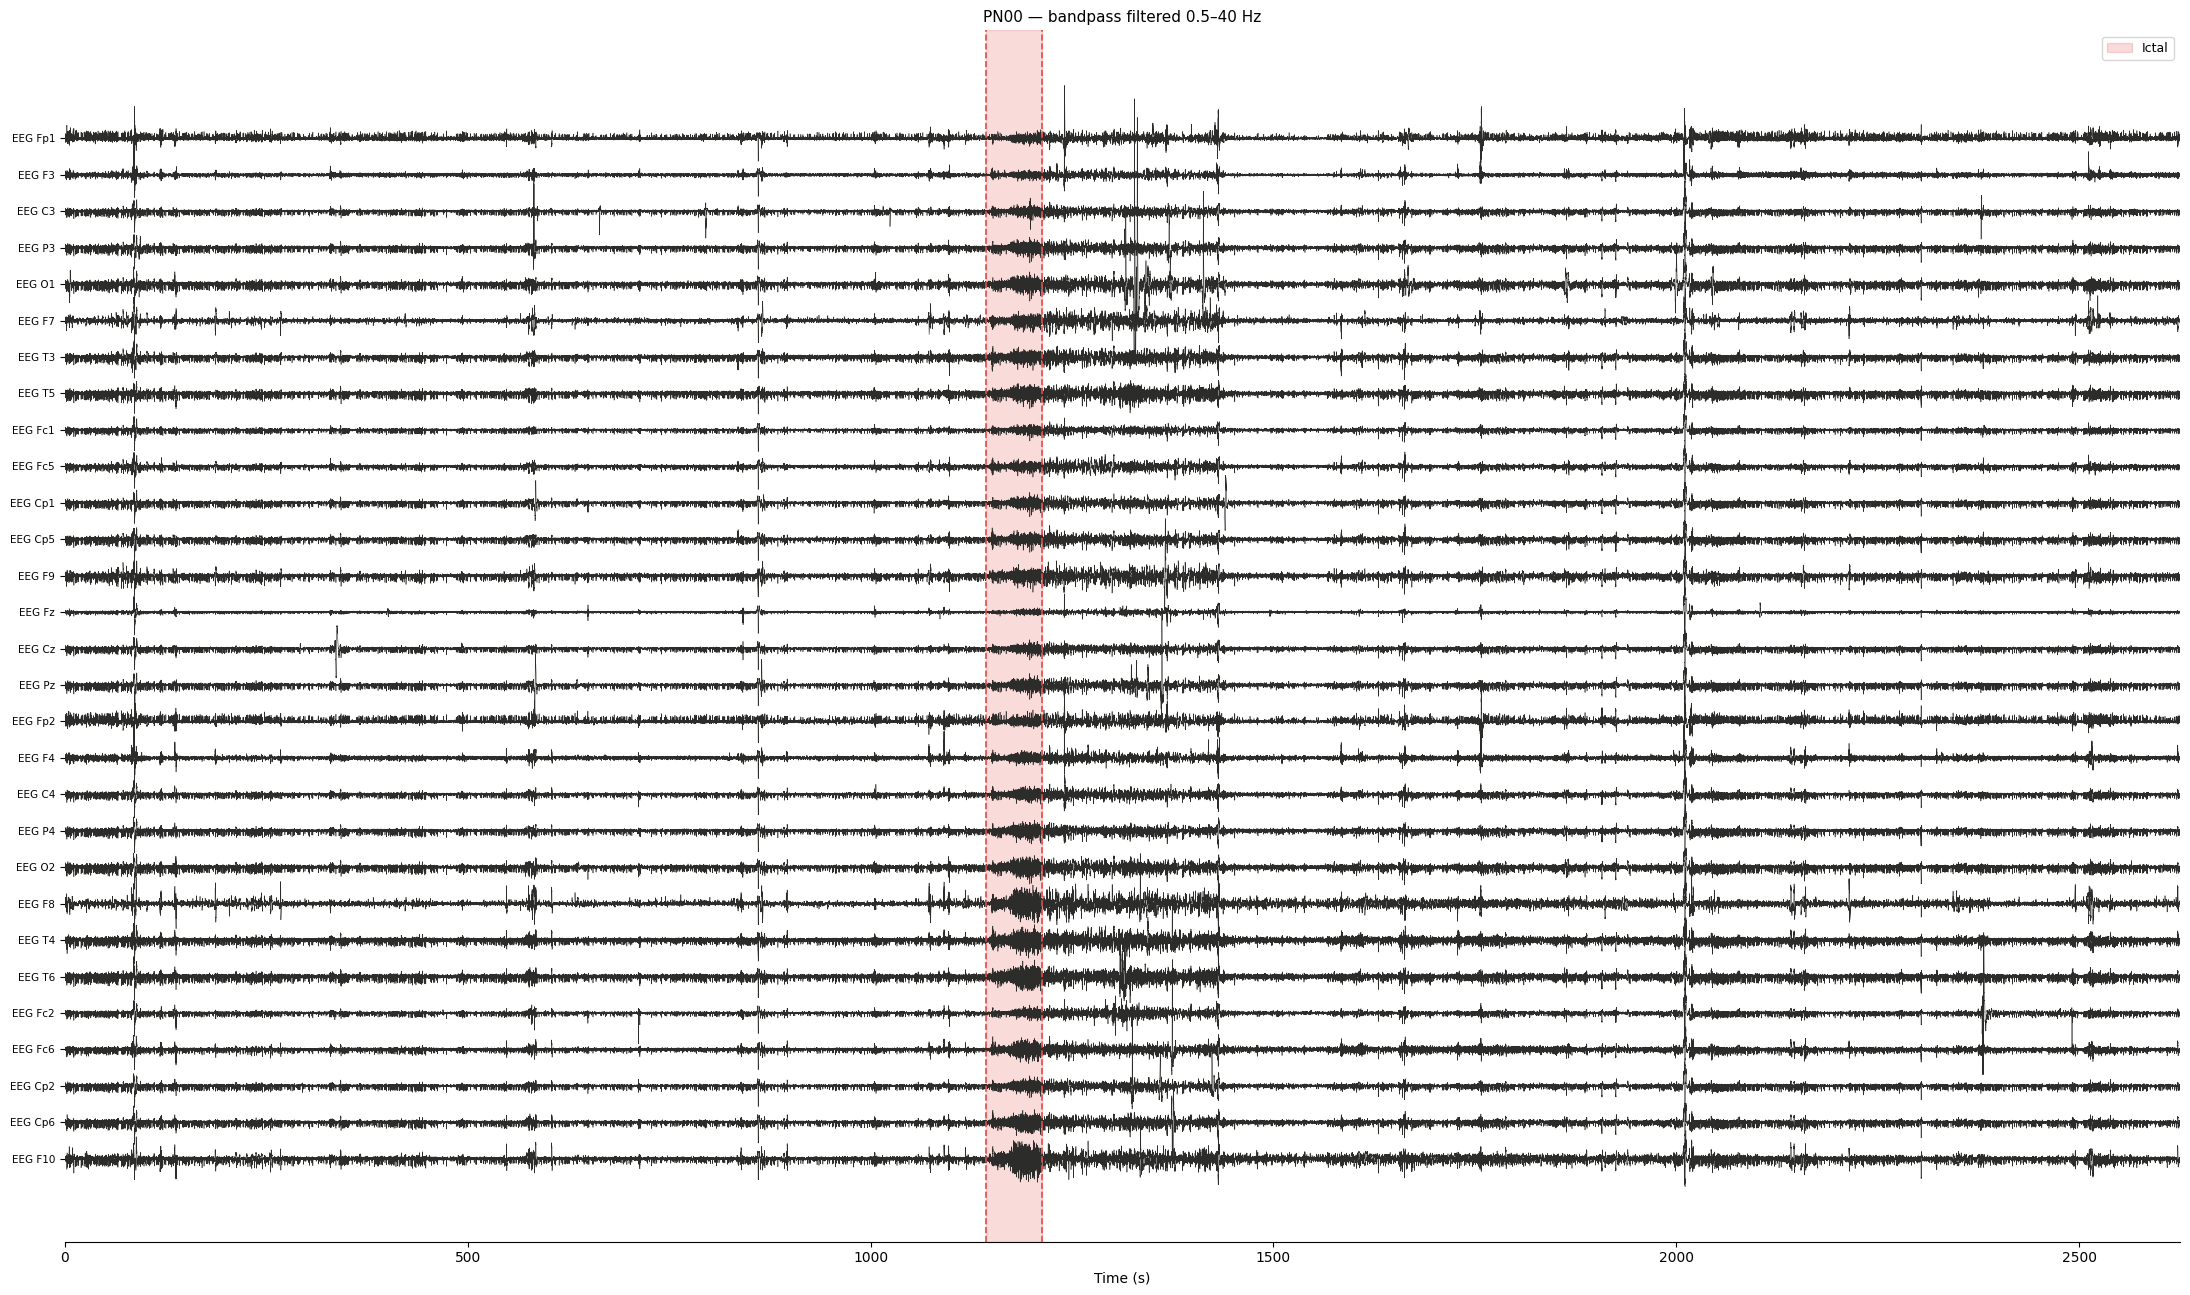

In [21]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
eeg_chs = [ch for ch in raw.ch_names if ch.startswith('EEG ')]
raw.drop_channels([ch for ch in raw.ch_names if ch not in eeg_chs])

# bandpass filter 0.5 - 40 Hz
raw.filter(0.5, 40.0, fir_design='firwin', verbose=False)

data, t  = raw.get_data(return_times=True)
data_uv  = data * 1e6
n_ch     = data_uv.shape[0]
ch_names = raw.ch_names
spacing  = 4.0

fig, ax = plt.subplots(figsize=(22, n_ch * 0.45))

for i, ch in enumerate(ch_names):
    offset = (n_ch - 1 - i) * spacing
    ax.plot(t, data_uv[i] * 0.01 + offset, lw=0.4, color='#2c2c2a', rasterized=True)

ax.axvspan(sz_start_sec, sz_end_sec, color='#E24B4A', alpha=0.2, label='Ictal')
ax.axvline(sz_start_sec, color='#E24B4A', lw=1.2, linestyle='--')
ax.axvline(sz_end_sec,   color='#E24B4A', lw=1.2, linestyle='--')

ax.set_yticks([(n_ch - 1 - i) * spacing for i in range(n_ch)])
ax.set_yticklabels(ch_names, fontsize=7.5)
ax.set_xlabel('Time (s)')
ax.set_title('PN00 — bandpass filtered 0.5–40 Hz', fontsize=11)
ax.set_xlim(t[0], t[-1])
ax.legend(fontsize=9)
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.show()

PC1: 50.5%  PC2: 13.5%  PC3: 5.6%
Total variance explained: 69.6%


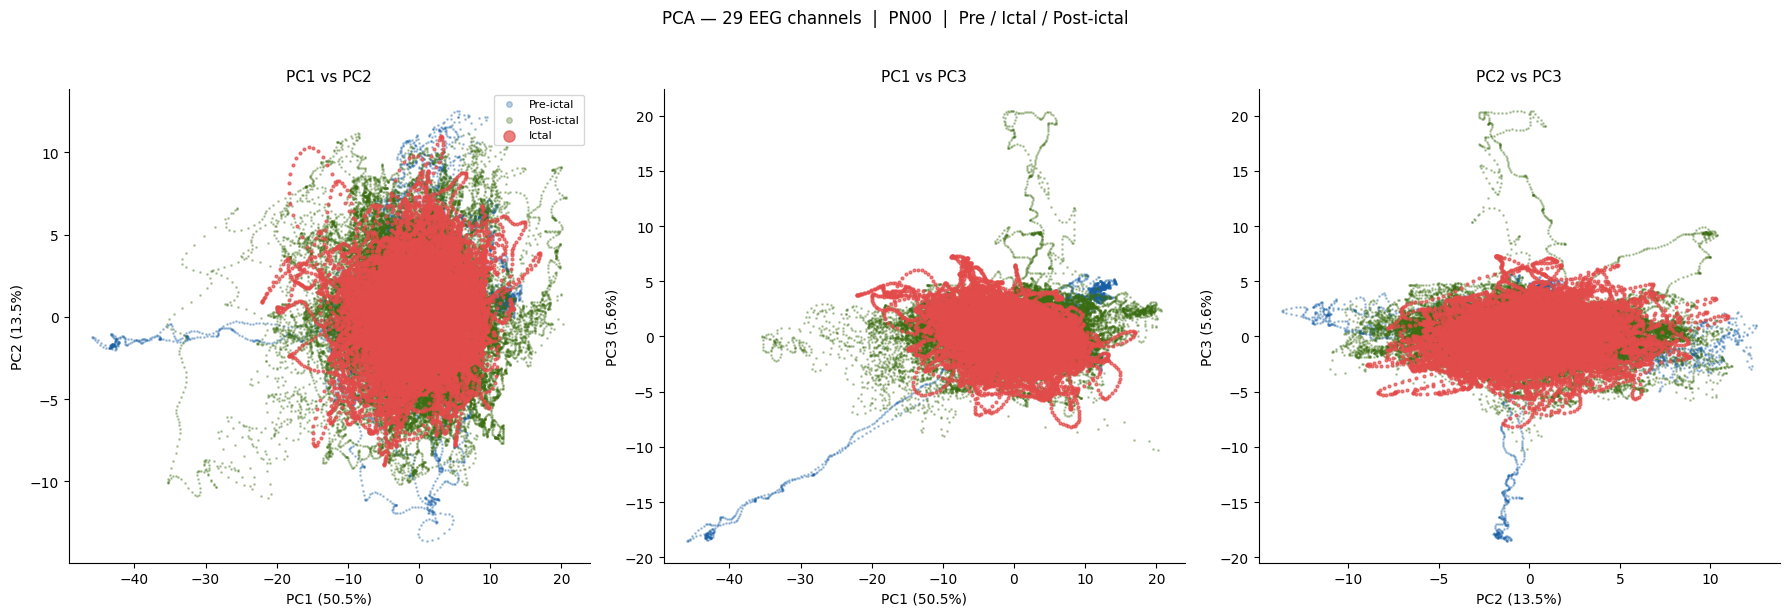

In [22]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── time windows ──────────────────────────────────────────────────────────────
sr = int(raw.info['sfreq'])

sz_start_samp = int(sz_start_sec * sr)
sz_end_samp   = int(sz_end_sec   * sr)
pre_start_samp = sz_start_samp - int(300 * sr)   # 5 min before
post_end_samp  = sz_end_samp   + int(300 * sr)   # 5 min after

data_uv = raw.get_data() * 1e6    # (29, n_samples)

# ── extract three segments ────────────────────────────────────────────────────
pre_data   = data_uv[:, pre_start_samp : sz_start_samp]   # preictal
ict_data   = data_uv[:, sz_start_samp  : sz_end_samp]     # ictal
post_data  = data_uv[:, sz_end_samp    : post_end_samp]   # post-ictal

# ── reshape: (n_samples, n_channels) for PCA ─────────────────────────────────
X_pre  = pre_data.T     # (n_samples, 29)
X_ict  = ict_data.T
X_post = post_data.T

# ── fit PCA on all three combined so they share the same component space ──────
X_all    = np.vstack([X_pre, X_ict, X_post])
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca      = PCA(n_components=3)
X_pca    = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f"PC1: {explained[0]:.1f}%  PC2: {explained[1]:.1f}%  PC3: {explained[2]:.1f}%")
print(f"Total variance explained: {explained.sum():.1f}%")

# ── split back into three segments ───────────────────────────────────────────
n_pre  = X_pre.shape[0]
n_ict  = X_ict.shape[0]

pca_pre  = X_pca[:n_pre]
pca_ict  = X_pca[n_pre : n_pre + n_ict]
pca_post = X_pca[n_pre + n_ict:]

# ── plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))

pairs = [
    (0, 1, 'PC1', 'PC2'),
    (0, 2, 'PC1', 'PC3'),
    (1, 2, 'PC2', 'PC3'),
]

for idx, (xi, yi, xlabel, ylabel) in enumerate(pairs):
    ax = fig.add_subplot(1, 3, idx + 1)

    ax.scatter(pca_pre[:,  xi], pca_pre[:,  yi],
               s=1, alpha=0.3, color='#185FA5', label='Pre-ictal',  rasterized=True)
    ax.scatter(pca_post[:, xi], pca_post[:, yi],
               s=1, alpha=0.3, color='#3B6D11', label='Post-ictal', rasterized=True)
    ax.scatter(pca_ict[:,  xi], pca_ict[:,  yi],
               s=4, alpha=0.7, color='#E24B4A', label='Ictal',      rasterized=True)

    ax.set_xlabel(f'{xlabel} ({explained[xi]:.1f}%)', fontsize=10)
    ax.set_ylabel(f'{ylabel} ({explained[yi]:.1f}%)', fontsize=10)
    ax.set_title(f'{xlabel} vs {ylabel}', fontsize=11)
    ax.spines[['top','right']].set_visible(False)
    if idx == 0:
        ax.legend(fontsize=8, markerscale=4)

plt.suptitle('PCA — 29 EEG channels  |  PN00  |  Pre / Ictal / Post-ictal',
             fontsize=12, fontweight='500', y=1.02)
plt.tight_layout()
plt.show()

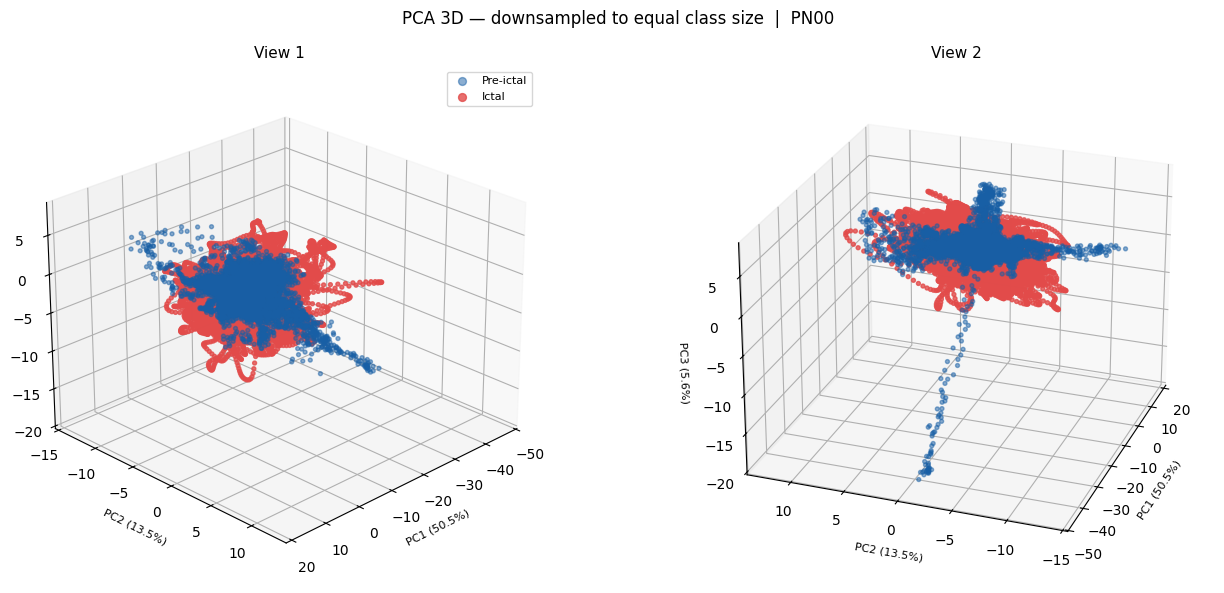

In [26]:
def downsample(arr, n):
    idx = np.linspace(0, len(arr)-1, n, dtype=int)
    return arr[idx]

n = len(pca_ict)   # match ictal size

pca_pre_ds  = downsample(pca_pre,  n)
pca_post_ds = downsample(pca_post, n)

fig = plt.figure(figsize=(14, 6))

for idx, (elev, azim, title) in enumerate([
    (25,  45,  'View 1'),
    (25, 200,  'View 2'),
]):
    ax = fig.add_subplot(1, 2, idx+1, projection='3d')

    ax.scatter(pca_pre_ds[:,0],  pca_pre_ds[:,1],  pca_pre_ds[:,2],
               s=8, alpha=0.5, color='#185FA5', label='Pre-ictal',  rasterized=True)
    # ax.scatter(pca_post_ds[:,0], pca_post_ds[:,1], pca_post_ds[:,2],
    #            s=8, alpha=0.5, color='#3B6D11', label='Post-ictal', rasterized=True)
    ax.scatter(pca_ict[:,0],     pca_ict[:,1],     pca_ict[:,2],
               s=8, alpha=0.8, color='#E24B4A', label='Ictal',      rasterized=True)

    ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)', fontsize=8)
    ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)', fontsize=8)
    ax.set_zlabel(f'PC3 ({explained[2]:.1f}%)', fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.view_init(elev=elev, azim=azim)
    if idx == 0:
        ax.legend(fontsize=8, markerscale=2)

plt.suptitle('PCA 3D — downsampled to equal class size  |  PN00',
             fontsize=12, fontweight='500')
plt.tight_layout()
plt.show()

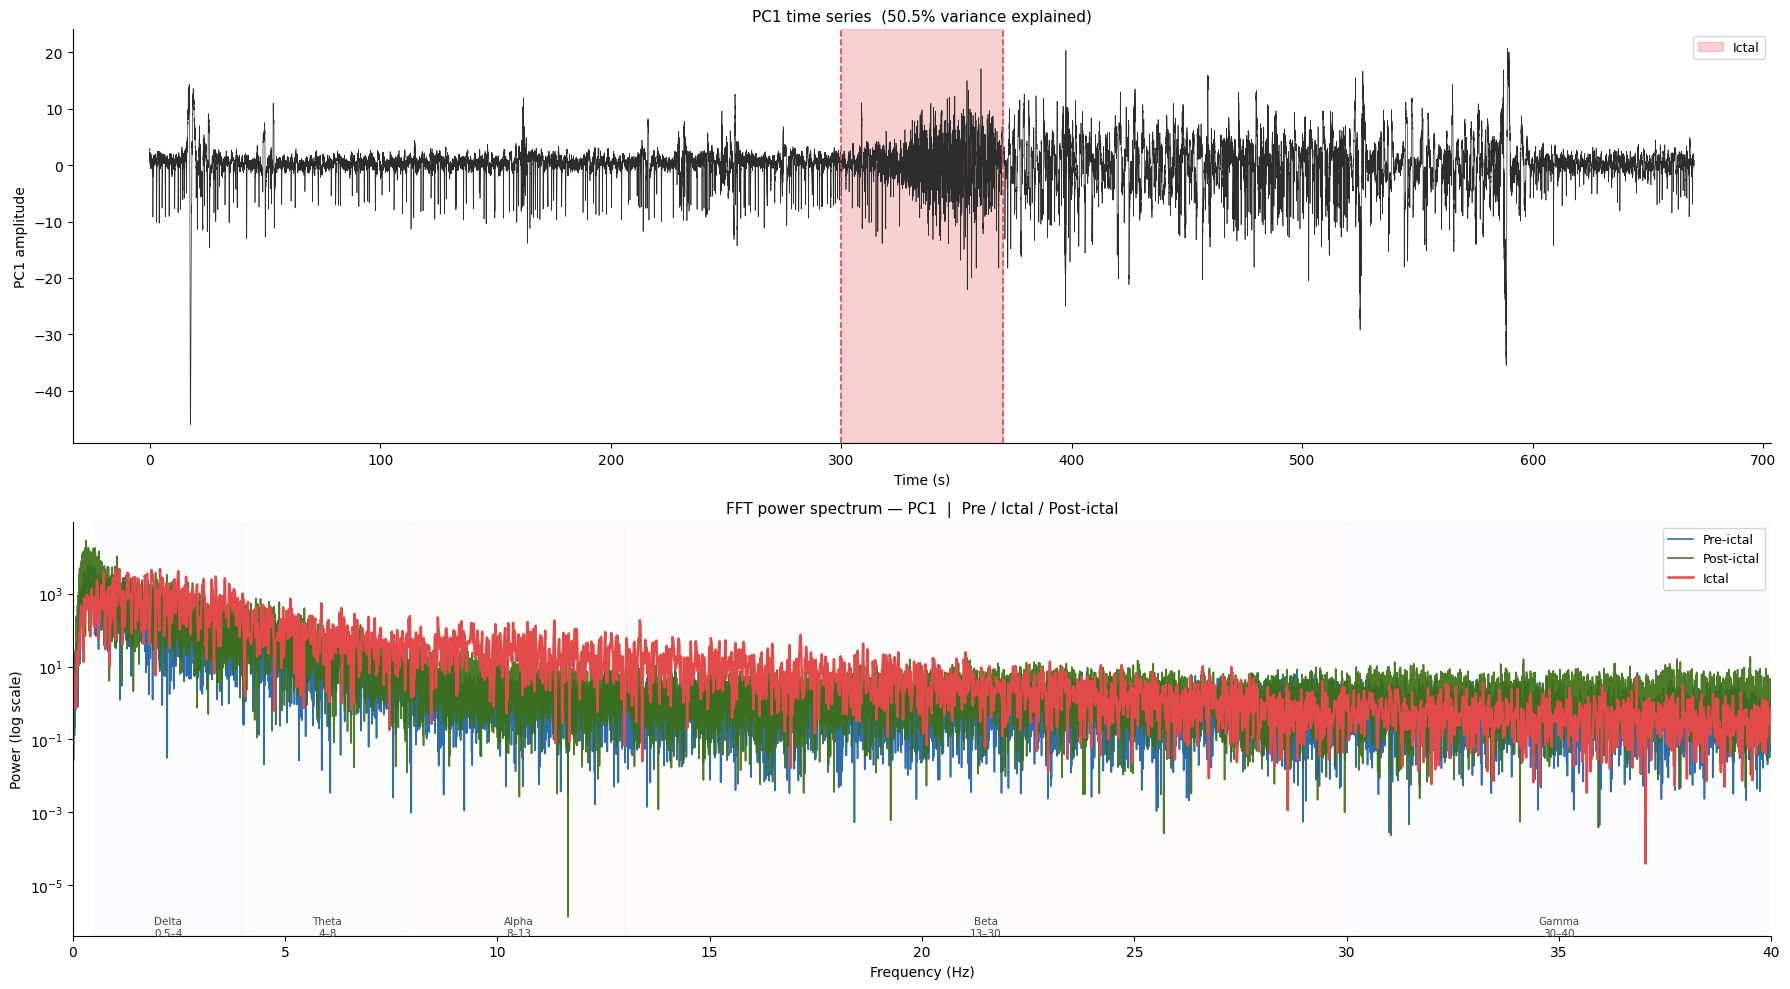

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ── take PC1 (best component — 50.5% variance) ───────────────────────────────
pc1_pre  = pca_pre[:,  0]
pc1_ict  = pca_ict[:,  0]
pc1_post = pca_post[:, 0]

# concatenate in order: pre → ictal → post
pc1_full  = np.concatenate([pc1_pre, pc1_ict, pc1_post])
n_total   = len(pc1_full)

# sample indices for each segment
idx_pre_end  = len(pc1_pre)
idx_ict_end  = idx_pre_end + len(pc1_ict)

# time axis
t_full = np.arange(n_total) / sr

# ── FFT per segment ───────────────────────────────────────────────────────────
def compute_fft(signal, sr):
    n      = len(signal)
    freqs  = np.fft.rfftfreq(n, d=1/sr)
    power  = np.abs(np.fft.rfft(signal)) ** 2
    power  = power / n   # normalize
    return freqs, power

freqs_pre,  power_pre  = compute_fft(pc1_pre,  sr)
freqs_ict,  power_ict  = compute_fft(pc1_ict,  sr)
freqs_post, power_post = compute_fft(pc1_post, sr)

# limit to 0–40 Hz
mask_pre  = freqs_pre  <= 40
mask_ict  = freqs_ict  <= 40
mask_post = freqs_post <= 40

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# ── top: PC1 time series with ictal highlighted ───────────────────────────────
ax1 = axes[0]
ax1.plot(t_full, pc1_full, lw=0.5, color='#2c2c2a', rasterized=True)
ax1.axvspan(t_full[idx_pre_end], t_full[idx_ict_end-1],
            color='#E24B4A', alpha=0.25, label='Ictal')
ax1.axvline(t_full[idx_pre_end],   color='#E24B4A', lw=1.2, linestyle='--')
ax1.axvline(t_full[idx_ict_end-1], color='#E24B4A', lw=1.2, linestyle='--')
ax1.set_xlabel('Time (s)', fontsize=10)
ax1.set_ylabel('PC1 amplitude', fontsize=10)
ax1.set_title(f'PC1 time series  ({explained[0]:.1f}% variance explained)', fontsize=11)
ax1.legend(fontsize=9)
ax1.spines[['top','right']].set_visible(False)

# ── bottom: FFT power spectrum for all 3 segments ────────────────────────────
ax2 = axes[1]
ax2.semilogy(freqs_pre[mask_pre],   power_pre[mask_pre],
             color='#185FA5', lw=1.2, alpha=0.9, label='Pre-ictal')
ax2.semilogy(freqs_post[mask_post], power_post[mask_post],
             color='#3B6D11', lw=1.2, alpha=0.9, label='Post-ictal')
ax2.semilogy(freqs_ict[mask_ict],   power_ict[mask_ict],
             color='#E24B4A', lw=1.8, alpha=1.0, label='Ictal')

# mark EEG frequency bands
bands = [
    (0.5,  4,  'Delta\n0.5–4'),
    (4,    8,  'Theta\n4–8'),
    (8,   13,  'Alpha\n8–13'),
    (13,  30,  'Beta\n13–30'),
    (30,  40,  'Gamma\n30–40'),
]
colors_band = ['#E6F1FB','#EAF3DE','#FAEEDA','#FAECE7','#EEEDFE']
for (flo, fhi, label), bc in zip(bands, colors_band):
    ax2.axvspan(flo, fhi, alpha=0.15, color=bc)
    ax2.text((flo+fhi)/2, ax2.get_ylim()[0] if ax2.get_ylim()[0] > 0 else 1e-3,
             label, ha='center', fontsize=7.5, color='#444441')

ax2.set_xlabel('Frequency (Hz)', fontsize=10)
ax2.set_ylabel('Power (log scale)', fontsize=10)
ax2.set_title('FFT power spectrum — PC1  |  Pre / Ictal / Post-ictal', fontsize=11)
ax2.set_xlim(0, 40)
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()